# Stage 05 — Evaluation: price-only vs. pattern-augmented, across two architectures

Loads the four saved runs and compares them head-to-head on the same held-out test period -- **without retraining anything**.

| Run label here | Saved as | Stage | Architecture | Features |
|---|---|---|---|---|
| `rnn_baseline` | `baseline` | 03 | `RNNForecaster` | price-only |
| `rnn_augmented` | `augmented` | 04 | `RNNForecaster` | price + `chart_patterns` flags |
| `patchtst_baseline` | `patchtst_baseline` | 06 | `PatchTSTForecaster` | price-only |
| `patchtst_augmented` | `patchtst_augmented` | 07 | `PatchTSTForecaster` | price + `chart_patterns` flags |

Compares:
- Test RMSE and directional (up/down) accuracy for all four
- Predicted vs. actual returns over the test period, per run
- Paired significance tests on per-example error -- within each architecture (does the pattern feature set help?) and across the two (does the architecture matter?)

**A note on interpretation:** every run was tuned independently, so a difference in test RMSE reflects the combination of *feature set + whatever configuration Optuna happened to find best for it* -- not a perfectly isolated ablation of the pattern features alone. That is the standard caveat for comparing independently-tuned pipelines, not a flaw specific to this setup.

**A second caveat, specific to these runs:** none of the training notebooks seed their RNGs, so each row below is a single unseeded draw. In stage 06's tuning the top five configurations spanned a val-RMSE range comparable to the gaps being compared here, so differences of that order should not be over-read.

## Environment setup (Google Colab)

Mounts the Drive and clones the repo via the `GITHUB_TOKEN` secret. No tuning happens in this notebook, so `ray`/`optuna` aren't needed here, but `requirements.txt` installs the full set regardless -- inexpensive, and keeps every notebook's setup cell identical.


In [6]:
import os
import sys

from google.colab import drive, userdata

drive.mount('/content/drive')

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = 'jesseingraham'
REPO_NAME = 'comp-653-stock-prediction-i'
REPO_PATH = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_PATH):
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git

os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

!pip install -r requirements.txt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports & configuration

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

from config import DRIVE_MODELS_PATH
from src.models.rnn_forecaster import RNNForecaster
from src.utils import artifacts, plotting

## 1. Load all four saved runs

`artifacts.find_latest_run` + `artifacts.load_run` reload each run's manifest, scaler, tuning trials, learning curves, and frozen test predictions -- exactly as `save_run` wrote them at the end of each stage. Nothing here re-trains anything.

The two PatchTST runs are loaded with `model_cls=None`. `load_run` rebuilds a model from `RNNForecaster`-shaped build args (`hidden_size`, `num_layers`, ...), which `PatchTSTForecaster` does not accept -- stages 06/07 record placeholder zeros for them. `PatchTSTForecaster` also isn't importable here: it is written into `src/models/` at runtime by a `%%writefile` cell in notebooks 06/07 and is not committed to the repo. Neither limitation matters for this notebook, which compares saved metrics and frozen predictions and never touches the model objects. `save_run` stores a plain dict of tensors rather than a pickled model, so `torch.load` does not need the class either.

The cell also asserts the provenance it depends on, so a stale artifact fails loudly here instead of quietly becoming a reported number.

In [8]:
# (label used here) -> (name it was saved under, class to rebuild).
# None skips model reconstruction -- see the note above.
RUN_SPECS = {
    'rnn_baseline':       ('baseline',           RNNForecaster),
    'rnn_augmented':      ('augmented',          RNNForecaster),
    'patchtst_baseline':  ('patchtst_baseline',  None),
    'patchtst_augmented': ('patchtst_augmented', None),
}

runs = {
    label: artifacts.load_run(artifacts.find_latest_run(name), model_cls=cls)
    for label, (name, cls) in RUN_SPECS.items()
}

PROVENANCE_FIELDS = ('num_features', 'dataset_file', 'n_test',
                     'num_samples', 'max_epochs', 'n_folds')
provenance = pd.DataFrame(
    [
        {
            'timestamp': run['manifest'].get('timestamp'),
            **{field: run['manifest'].get('provenance', {}).get(field)
               for field in PROVENANCE_FIELDS},
        }
        for run in runs.values()
    ],
    index=list(runs),
)
display(provenance)

# The augmented feature set is 11 columns: 6 base + 5 pattern flags. It was 12
# before the pattern-lookahead fix dropped head and shoulders, so a 12 here means
# the run predates that fix, still carries leaked future information, and must not
# be reported.
EXPECTED_FEATURES = {'rnn_baseline': 6, 'rnn_augmented': 11,
                     'patchtst_baseline': 6, 'patchtst_augmented': 11}
for label, expected in EXPECTED_FEATURES.items():
    found = runs[label]['manifest'].get('provenance', {}).get('num_features')
    assert found == expected, (
        f"{label}: expected {expected} features but the saved run has {found}. "
        "This artifact was built from a stale windowed dataset -- re-run its stage "
        "before reporting it."
    )

# Both arms of an architecture must have been tuned on the same budget, or a
# metric difference between them is partly a compute difference.
BUDGET_FIELDS = ('num_samples', 'max_epochs', 'n_folds')
for arch in ('rnn', 'patchtst'):
    budgets = {
        arm: [runs[f'{arch}_{arm}']['manifest'].get('provenance', {}).get(f)
              for f in BUDGET_FIELDS]
        for arm in ('baseline', 'augmented')
    }
    assert budgets['baseline'] == budgets['augmented'], (
        f"{arch}: tuning budgets differ between arms -- {BUDGET_FIELDS} were "
        f"{budgets['baseline']} for baseline and {budgets['augmented']} for "
        "augmented. The comparison is confounded on compute; re-run the "
        "under-tuned arm before reading anything into the gap."
    )

print('Provenance OK: feature counts as expected, tuning budgets matched within '
      'each architecture.')

,timestamp,num_features,dataset_file,n_test,num_samples,max_epochs,n_folds
rnn_baseline,20260809_060531,6,sp500_windows_baseline.npz,742,30,50,4
rnn_augmented,20260814_202532,11,sp500_windows_augmented.npz,742,30,50,4
patchtst_baseline,20260815_215721,6,sp500_windows_baseline.npz,742,30,50,4
patchtst_augmented,20260815_221425,11,sp500_windows_augmented.npz,742,30,50,4


Provenance OK: feature counts as expected, tuning budgets matched within each architecture.


## 2. Headline metrics, side by side

Straight from each run's `manifest['metrics']`, written by `save_run` at the end of stages 03/04/06/07 -- test RMSE, directional accuracy, and the tuning objective (`best_val_rmse`) that Optuna minimized during walk-forward CV.

Deltas are computed against each architecture's **own** price-only run, because the pattern features are the ablation under test and the architecture is not. Comparing a PatchTST run against the RNN baseline would mix the two effects.

In [9]:
summary = pd.DataFrame(
    [runs[label]['manifest']['metrics'] for label in runs], index=list(runs)
)

# Recover metrics that older manifests stored as text. save_run's numeric coercion
# tested isinstance(value, (int, float)), which np.float64 passes but np.float32
# does not -- and test RMSE is np.float32, since it comes from np.sqrt(np.mean(...))
# over float32 predictions. json.dumps(default=str) then wrote it as a string. The
# values are exact, only the type is wrong, so parsing them back is lossless and no
# run needs repeating. save_run has since been fixed, so this is a no-op for runs
# saved after that fix.
summary = summary.apply(pd.to_numeric, errors='coerce')
assert not summary.isna().any().any(), (
    "Some metric values could not be read as numbers:\n"
    f"{summary[summary.isna().any(axis=1)]}"
)

OWN_BASELINE = {
    'rnn_baseline':       'rnn_baseline',
    'rnn_augmented':      'rnn_baseline',
    'patchtst_baseline':  'patchtst_baseline',
    'patchtst_augmented': 'patchtst_baseline',
}
summary['rmse_delta_vs_own_baseline'] = [
    summary.loc[label, 'test_rmse'] - summary.loc[OWN_BASELINE[label], 'test_rmse']
    for label in summary.index
]
summary['dir_acc_delta_vs_own_baseline'] = [
    summary.loc[label, 'test_directional_accuracy']
    - summary.loc[OWN_BASELINE[label], 'test_directional_accuracy']
    for label in summary.index
]
summary.round(6)

,test_rmse,test_directional_accuracy,best_val_rmse,rmse_delta_vs_own_baseline,dir_acc_delta_vs_own_baseline
rnn_baseline,0.009626,0.555256,0.010813,0.000000,0.000000
rnn_augmented,0.009664,0.444744,0.010810,0.000038,-0.110512
patchtst_baseline,0.013900,0.470350,0.012559,0.000000,0.000000
patchtst_augmented,0.009907,0.444744,0.011174,-0.003992,-0.025606


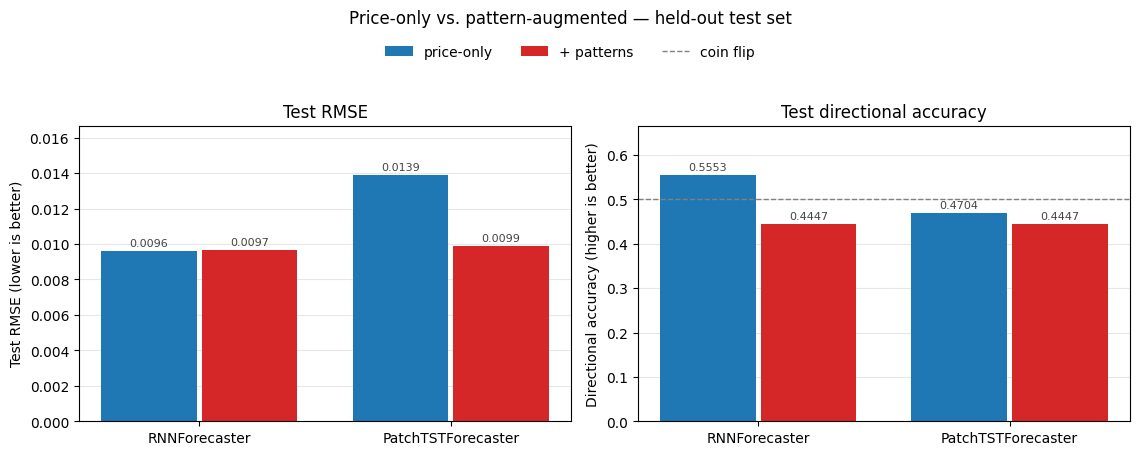

In [10]:
# 2x2 design: architecture as the group, feature set as the bars within it, so the
# ablation under test sits side by side. Colour encodes the feature set only and is
# assigned in fixed order; the pair is checked for colour-vision separation
# (protanopia dE 21.1, well clear of the dE 8 floor).
ARCHITECTURES = [('rnn', 'RNNForecaster'), ('patchtst', 'PatchTSTForecaster')]
ARMS = [('baseline', 'price-only', '#1f77b4'), ('augmented', '+ patterns', '#d62728')]

positions = np.arange(len(ARCHITECTURES))
width, gap = 0.38, 0.02

panels = [
    ('test_rmse', 'Test RMSE (lower is better)', 'Test RMSE', None),
    ('test_directional_accuracy', 'Directional accuracy (higher is better)',
     'Test directional accuracy', 0.5),
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
handles, labels = [], []

for ax, (metric, ylabel, title, reference_line) in zip(axes, panels):
    heights = []
    for i, (arm, arm_label, colour) in enumerate(ARMS):
        offset = (i - 0.5) * (width + gap)
        values = [summary.loc[f'{arch}_{arm}', metric] for arch, _ in ARCHITECTURES]
        heights += values
        bars = ax.bar(positions + offset, values, width, label=arm_label, color=colour)
        # Direct labels: four bars per panel, so each can carry its value without
        # crowding. Text stays in neutral ink rather than the series colour.
        ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=8, color='#444444')
    if reference_line is not None:
        ax.axhline(reference_line, color='gray', linestyle='--', linewidth=1,
                   label='coin flip')
        heights.append(reference_line)
    ax.set_xticks(positions, [name for _, name in ARCHITECTURES])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_axisbelow(True)                       # keep the grid behind the bars
    # Headroom so the direct labels clear the top spine. The baseline stays at zero:
    # truncating a bar axis would misrepresent the ratios between bars.
    ax.set_ylim(0, max(heights) * 1.20)
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

# One shared legend above the panels. Both panels use the same encoding, and a
# per-axes legend overlaps the bars in the right-hand panel.
fig.legend(handles, labels, loc='upper center', ncol=len(labels), frameon=False,
           bbox_to_anchor=(0.5, 0.93))
fig.suptitle('Price-only vs. pattern-augmented — held-out test set')
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

## 3. Predictions vs. actual, over the test period

Each run's frozen test-set predictions (`test_predictions.csv`, written by `save_run`) plotted against actual log returns.

All four share the same test window: stage 02 builds both feature sets from the same cleaned data with the same `TEST_FRAC`, and the pattern columns are dense (no NaNs), so they don't change which windows survive the NaN drop. The next cell asserts that rather than assuming it -- matching lengths *and* identical target values, since matching lengths alone would not catch a misaligned window.

In [11]:
preds = {label: run['predictions'] for label, run in runs.items()}

lengths = {label: len(frame) for label, frame in preds.items()}
assert len(set(lengths.values())) == 1, (
    f"Runs have different test-set lengths: {lengths}. All four should share the "
    "same test window -- re-check TEST_FRAC and the stage 02 feature files before "
    "trusting anything below."
)

# Stronger than matching lengths: the actual targets must be identical, or the runs
# are not scored on the same examples and every paired test below is meaningless.
reference = preds['rnn_baseline']['target_0'].to_numpy()
for label, frame in preds.items():
    assert np.allclose(frame['target_0'].to_numpy(), reference, atol=1e-6), (
        f"{label} has different test targets than rnn_baseline -- the runs are not "
        "aligned to the same test window."
    )

dates = (pd.to_datetime(preds['rnn_baseline']['date'])
         if 'date' in preds['rnn_baseline'] else None)
print(f"All four runs aligned on {lengths['rnn_baseline']} shared test examples.")

All four runs aligned on 742 shared test examples.


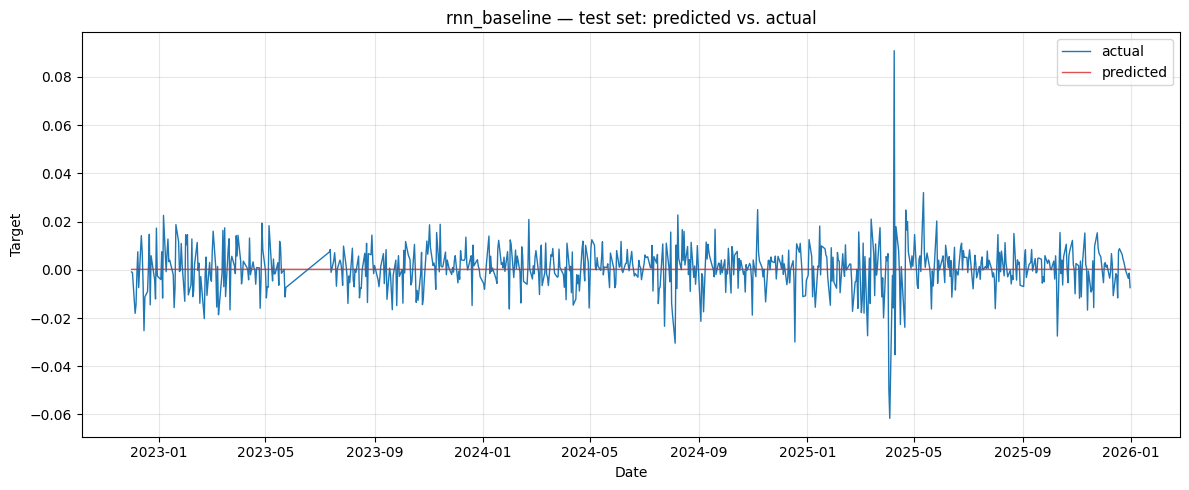

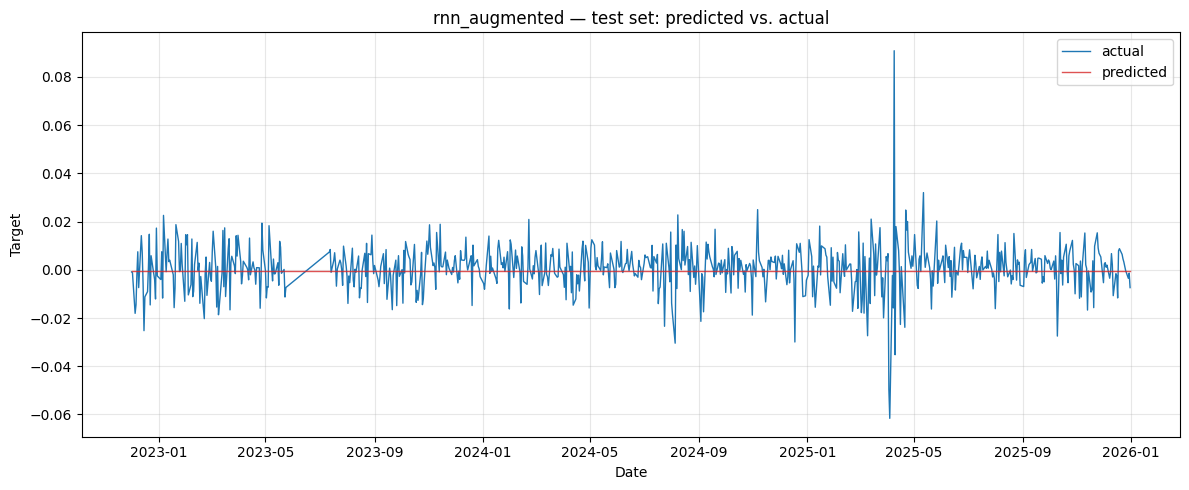

In [12]:
for label in ('rnn_baseline', 'rnn_augmented'):
    plotting.plot_predictions_vs_actual(
        preds[label]['target_0'], preds[label]['pred_0'],
        index=dates, title=f'{label} — test set: predicted vs. actual',
    )
    plt.show()

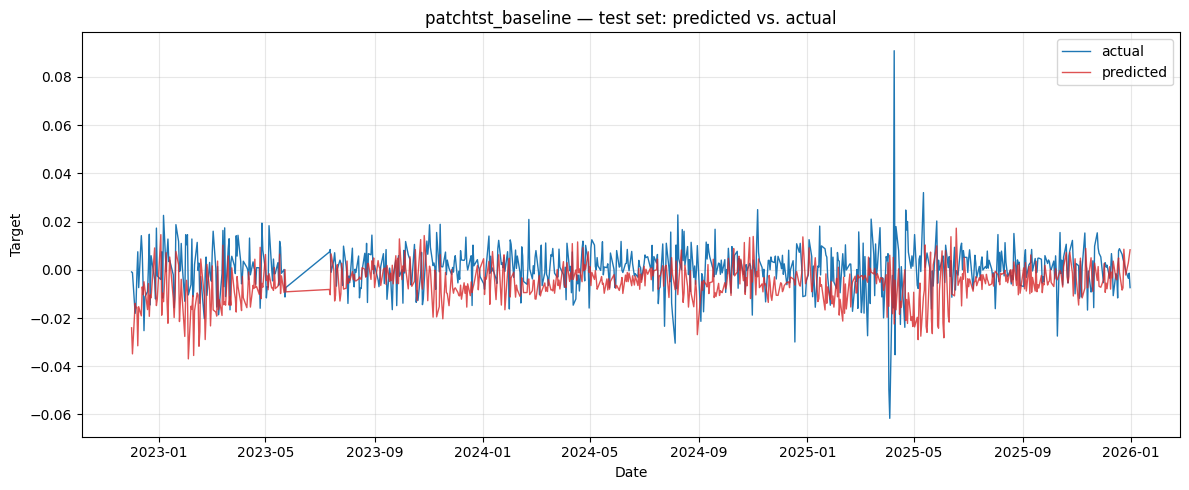

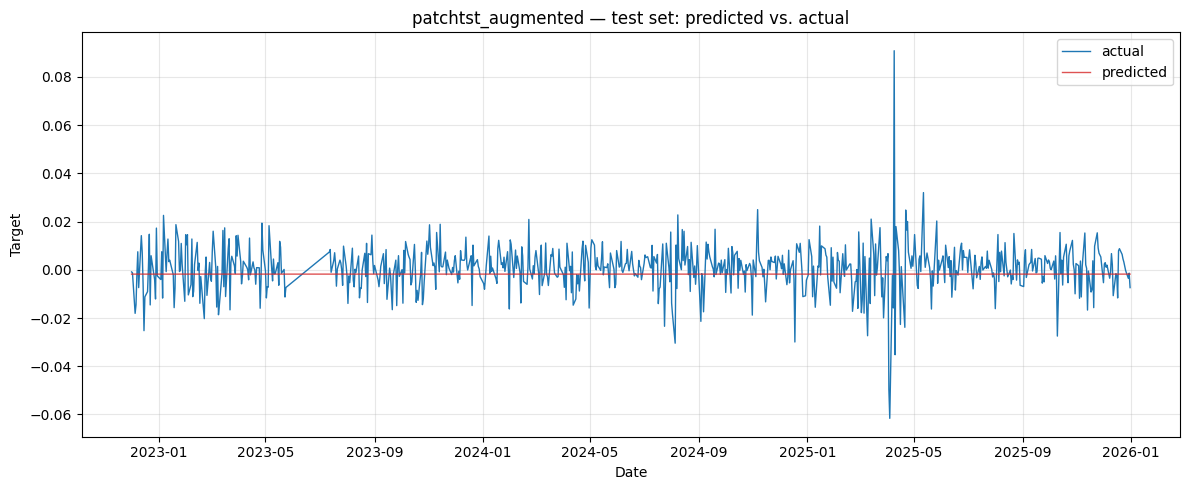

In [13]:
for label in ('patchtst_baseline', 'patchtst_augmented'):
    plotting.plot_predictions_vs_actual(
        preds[label]['target_0'], preds[label]['pred_0'],
        index=dates, title=f'{label} — test set: predicted vs. actual',
    )
    plt.show()

## 4. Are the differences in error real, or noise?

A bar-chart gap alone can't say whether a model is *actually* better or just landed on a luckier tuning draw. Since every run is scored on the same test examples, a **paired** comparison is the right tool: for each test date take each model's squared error and run a paired t-test on the two error series.

Four comparisons are run — two feature ablations (one per architecture) and two architecture comparisons (one per feature set):

- **p < 0.05:** the two runs' errors differ by more than chance would explain on this test set.
- **p ≥ 0.05:** not enough evidence here to call the error series different — the RMSE gap could plausibly be noise.

Because four tests are run at once, the chance of at least one false positive is higher than the nominal 5%. A Bonferroni-adjusted threshold (0.05 / 4 = 0.0125) is reported alongside the raw p-value; treat the adjusted column as the stricter reading.

This is statistical significance, not practical significance — a real but tiny RMSE difference may not justify the extra complexity of the pattern features, and that's a judgment call for the write-up, not something a p-value settles.

In [14]:
squared_error = {label: (frame['target_0'] - frame['pred_0']) ** 2
                 for label, frame in preds.items()}

COMPARISONS = [
    ('rnn_baseline', 'rnn_augmented', 'patterns: RNN'),
    ('patchtst_baseline', 'patchtst_augmented', 'patterns: PatchTST'),
    ('rnn_baseline', 'patchtst_baseline', 'architecture: price-only'),
    ('rnn_augmented', 'patchtst_augmented', 'architecture: augmented'),
]
ALPHA = 0.05
adjusted = ALPHA / len(COMPARISONS)

rows = []
for left, right, question in COMPARISONS:
    t_stat, p_value = stats.ttest_rel(squared_error[left], squared_error[right])
    rows.append({
        'question': question,
        'comparison': f'{left} vs {right}',
        'mse_left': squared_error[left].mean(),
        'mse_right': squared_error[right].mean(),
        'lower_error': left if squared_error[left].mean() < squared_error[right].mean() else right,
        't': t_stat,
        'p': p_value,
        'sig_raw': p_value < ALPHA,
        'sig_bonferroni': p_value < adjusted,
    })

n_examples = len(squared_error['rnn_baseline'])
print(f"Paired t-tests on per-example squared error (n={n_examples} shared test examples)")
print(f"Bonferroni threshold for {len(COMPARISONS)} tests: p < {adjusted:.4f}\n")
pd.DataFrame(rows).set_index('question').round(6)

Paired t-tests on per-example squared error (n=742 shared test examples)
Bonferroni threshold for 4 tests: p < 0.0125



,comparison,mse_left,mse_right,lower_error,t,p,sig_raw,sig_bonferroni
question,,,,,,,,
patterns: RNN,rnn_baseline vs rnn_augmented,0.000093,0.000093,rnn_baseline,-1.887650,0.059463,False,False
patterns: PatchTST,patchtst_baseline vs patchtst_augmented,0.000193,0.000098,patchtst_augmented,9.619860,0.000000,True,True
architecture: price-only,rnn_baseline vs patchtst_baseline,0.000093,0.000193,rnn_baseline,-9.522781,0.000000,True,True
architecture: augmented,rnn_augmented vs patchtst_augmented,0.000093,0.000098,rnn_augmented,-4.687815,0.000003,True,True


## 5. Hyperparameters each run settled on

Each run was tuned independently, so it's worth checking *what* Optuna found best for each feature set. Similar configs within an architecture suggest the pattern features didn't meaningfully change the optimization landscape; very different configs suggest they did.

The two architectures have disjoint hyperparameters (`hidden_size`/`num_layers` vs `patch_len`/`stride`/`d_model`/`n_heads`), so they get separate tables rather than one sparse table full of NaNs.

For the PatchTST rows, `stride <= patch_len` holds by construction — the search space was constrained so patches tile the look-back window instead of leaving gaps.

In [15]:
rnn_configs = pd.DataFrame(
    [runs[label]['config'] for label in ('rnn_baseline', 'rnn_augmented')],
    index=['rnn_baseline', 'rnn_augmented'],
)
patchtst_configs = pd.DataFrame(
    [runs[label]['config'] for label in ('patchtst_baseline', 'patchtst_augmented')],
    index=['patchtst_baseline', 'patchtst_augmented'],
)

display(rnn_configs)
display(patchtst_configs)

,hidden_size,num_layers,dropout,lr,batch_size,weight_decay
rnn_baseline,128,3,0.410497,0.000156,128,0.000025
rnn_augmented,128,3,0.010384,0.000843,128,0.000845


,patch_len,stride,d_model,n_heads,n_layers,dropout,lr,batch_size,weight_decay
patchtst_baseline,8,4,64,4,2,0.201212,0.002313,128,0.000714
patchtst_augmented,4,2,32,4,2,0.403914,0.003344,32,0.000221


## Summary

Four runs -- price-only and pattern-augmented, for both `RNNForecaster` and `PatchTSTForecaster` -- compared head-to-head on the same held-out test period without retraining any of them: provenance checks, headline metrics, per-run prediction plots, paired significance tests, and the winning hyperparameters.

**Reading the result:** take section 2 and section 4 together. A numeric edge for an augmented run only supports the "chart patterns help" conclusion if it is also statistically distinguishable from noise on this test set -- and, given four simultaneous tests, ideally under the Bonferroni column rather than the raw one. If the arms are close in section 2 *and* the relevant test in section 4 is not significant, the honest conclusion is that this test period gives no clear evidence either way, which is itself a legitimate finding to report.

**What this comparison does not control for:** each run is a single unseeded draw, and each was tuned independently. The provenance checks in section 1 guarantee the two arms of an architecture saw the same tuning budget and the same test window, which removes the compute and data confounds -- but not run-to-run variance. Reporting the direction and rough size of an effect is defensible here; reporting a precise RMSE delta as though it were reproducible is not.